<a href="https://colab.research.google.com/github/raul-miranda/DS201-2026/blob/main/Week%203/Week3_part2_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Class 4 – Linear Regression in Python (Student Notebook)

**Audience:** R users transitioning to Python

**Focus:** Simple and Multiple Linear Regression (continuous outcomes)

> ✍️ **Instructions:** Complete all TODO sections. Reflection questions are required and assess conceptual understanding.

---

## 1. Learning Objectives

By the end of this lesson, you should be able to:

* Translate R `lm()` models into Python using `statsmodels`
* Fit simple and multiple linear regression models in Python
* Compare inference-focused vs prediction-focused workflows
* Interpret coefficients consistently across R and Python
* Evaluate predictive performance using appropriate metrics

---

## 2. Setup

In [2]:
# TODO: Run this cell
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## 3. Data

In **R**, you would typically load data like this:

```r
df <- read.csv("housing.csv")
```

### Python Translation

In [3]:
# TODO: Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")

df.head()


,listing_id,price,size,bedrooms,neighborhood,type
0,100001,1500000,1280.741760,1.0,Suburb,Townhouse
1,100002,1500000,1406.283113,2.0,Uptown,SingleFamily
2,100003,1500000,4146.825713,6.0,Suburb,MultiFamily
3,100004,1500000,3946.599818,6.0,Suburb,SingleFamily
4,100005,1500000,1243.751760,1.0,Downtown,MultiFamily



Assume the following variables:

* `price` (continuous outcome)
* `size` (continuous predictor)
* `bedrooms` (numeric predictor)
* `neighborhood` (categorical predictor)

---

## 4. Conceptual Review: What Linear Regression Models

### In R

```r
lm(price ~ size, data = df)
```

* Models the *expected value* of a continuous outcome
* Coefficients represent conditional mean differences

### Key idea

✏️ **Reflection:** How does this interpretation change (or not) when we move to Python?

---

## 5. Exploratory Analysis


<Axes: xlabel='size', ylabel='price'>

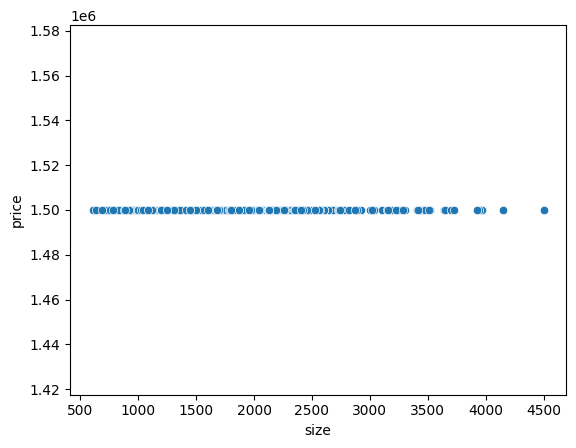

In [3]:
sns.scatterplot(data=df, x="size", y="price")


✏️ **Reflection:** Does a linear relationship seem plausible?

---

## 6. Simple Linear Regression (Inference)

### R Reference

```r
model_r <- lm(price ~ size, data = df)
summary(model_r)
```

### Python Translation (statsmodels)

In [5]:
import statsmodels.formula.api as smf

# TODO: Fit a simple linear regression using statsmodels
model_sm_simple = smf.ols(formula="price ~ size", data=df).fit()

model_sm_simple.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:125: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = stats.skew(resids, axis=axis)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:126: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = 3 + stats.kurtosis(resids, axis=axis)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1687: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = skew(a, axis, _no_deco=True)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1792: RuntimeWarning: Precision loss occurred in moment calculation due t

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                    -545.0
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               1.00
Time:                        00:33:33   Log-Likelihood:                 10598.
No. Observations:                 547   AIC:                        -2.119e+04
Df Residuals:                     545   BIC:                        -2.118e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     1.5e+06   1.08e-10   1.39e+16      0.000     1.5e+06     1.5e+06
size        4.441e-15   5.69e-14      0.078      0.938   -1.07e-13    1.16e-13
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   0.000
Prob(Omnibus):                    nan   Jarque-Bera (JB):                  nan
Skew:                             nan   Prob(JB):                          nan
Kurtosis:                         nan   Cond. No.                     5.14e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.14e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

✏️ **Reflection:** Identify two similarities between `summary(model_r)` and the Python output.

---

## 7. Multiple Linear Regression (Inference)

### R Reference

```r
lm(price ~ size + bedrooms + neighborhood, data = df)
```

### Python Translation (statsmodels)



In [ ]:
# TODO: Fit a multiple linear regression using statsmodels
model_sm_multiple = ...

# TODO: Display the summary


✏️ **Reflection:** What does the coefficient on `size` represent *holding other variables constant*?

---

## 8. Categorical Predictors

In R, factors are handled automatically.

In Python:

* Formulas handle categoricals using `C()`

In [6]:
# Example
# price ~ size + C(neighborhood)
smf.ols(formula="price ~ size + C(neighborhood)", data=df).fit().summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                        -inf
Model:                            OLS   Adj. R-squared:                   -inf
Method:                 Least Squares   F-statistic:                    -108.2
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               1.00
Time:                        00:37:30   Log-Likelihood:                 8435.8
No. Observations:                 547   AIC:                        -1.686e+04
Df Residuals:                     541   BIC:                        -1.683e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        1.5e+06   6.53e-09    2.3e+14      0.000     1.5e+06     1.5e+06
C(neighborhood)[T.Midtown]     1.844e-10   6.61e-09      0.028      0.978   -1.28e-08    1.32e-08
C(neighborhood)[T.Suburb]      2.547e-10   6.04e-09      0.042      0.966   -1.16e-08    1.21e-08
C(neighborhood)[T.Uptown]      4.343e-10   6.54e-09      0.066      0.947   -1.24e-08    1.33e-08
C(neighborhood)[T.Waterfront]  4.584e-10   8.41e-09      0.055      0.957   -1.61e-08     1.7e-08
size                          -2.514e-11   3.04e-12     -8.261      0.000   -3.11e-11   -1.92e-11
==============================================================================
Omnibus:                      107.390   Durbin-Watson:                   0.272
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              188.368
Skew:                           1.160   Prob(JB):                     1.25e-41
Kurtosis:                       4.698   Cond. No.                     1.03e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.03e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


✏️ **Reflection:** What is the reference category, and how can you tell?

---

## 9. Prediction-Focused Linear Regression (scikit-learn)

### R Analogy

In R, prediction-focused workflows often use:

* `caret`
* `tidymodels`

### Python Workflow


In [ ]:
# TODO: Define predictors and outcome
X = ...
y = ...

# TODO: Create train/test split
X_train, X_test, y_train, y_test = ...

In [ ]:
# TODO: Fit a scikit-learn linear regression model
model_sk = ...
model_sk.fit(X_train, y_train)

In [ ]:
# TODO: Generate predictions
y_pred = ...

## 10. Model Evaluation

In [ ]:
# TODO: Compute RMSE


# TODO: Compute R^2

✏️ **Reflection:** Why are these metrics not provided automatically by statsmodels?

---

## 11. Comparison Table (Fill In)

| Feature          | R (`lm`) | statsmodels | scikit-learn |
| ---------------- | -------- | ----------- | ------------ |
| Primary goal     |          |             |              |
| Uses formulas    |          |             |              |
| Train/test split |          |             |              |
| Output           |          |             |              |

---

## 12. Active Learning (15–20 minutes)

**Pair activity:**

1. One student explains a regression coefficient in plain language
2. The other explains the difference between inference and prediction
3. Together, decide which tool you would use for:

   * Estimating housing price effects
   * Predicting housing prices

Be prepared to justify your choices.

---

## 13. Takeaways

* Linear regression works the same in R and Python
* statsmodels ≈ `lm`
* scikit-learn ≈ prediction-focused R workflows
* Tool choice depends on analytical goals
